# Calibration Cox

**This notebook assesses calibration performance of the cox survival model and recalibrates predictions using isotonic regression for patients with advanced head and neck cancer receiving first-line pembrolizumab plus chemotherapy or pembrolizumab.**

In [1]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from scipy.stats import linregress
from sklearn.model_selection import StratifiedKFold
from joblib import Parallel, delayed
from sklearn.isotonic import IsotonicRegression
from sksurv.metrics import brier_score

from utils.calibration import calculate_calibration_curve, calibrate_survival_predictions

## Import Data

In [2]:
survival_predictions_df = pd.read_csv('../outputs/cox_survival_predictions.csv')

In [3]:
survival_predictions_df = survival_predictions_df[['PatientID', 'risk_score', 'psurv_180']]

In [4]:
survival_predictions_df.shape

(8718, 3)

In [5]:
dtype_map = pd.read_csv('../outputs/pembrochemo_pembro_features_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
pembro_pembrochemo_df = pd.read_csv('../outputs/pembrochemo_pembro_features_df.csv', dtype = dtype_map)

In [6]:
pembro_pembrochemo_df.shape

(1736, 162)

In [7]:
df = pd.merge(pembro_pembrochemo_df, survival_predictions_df, on = 'PatientID', how = 'left')

In [8]:
df.shape

(1736, 164)

In [9]:
df = df.query('adv_diagnosis_year <= 2021')

In [10]:
df.shape

(1257, 164)

## Raw Calibration Assessment

In [11]:
cal_df = calculate_calibration_curve(df, 'psurv_180', 180)

In [12]:
cal_df

,bin,predicted,observed,n,obs_lo,obs_hi
0,"(-0.0007379999999999999, 0.554]",0.416146,0.353508,126,0.261032,0.437420
1,"(0.554, 0.659]",0.612830,0.519054,126,0.424925,0.601248
2,"(0.659, 0.716]",0.689126,0.605764,125,0.509815,0.683333
3,"(0.716, 0.752]",0.733829,0.717065,126,0.627233,0.788873
4,"(0.752, 0.78]",0.765392,0.683079,126,0.588339,0.753644
5,"(0.78, 0.805]",0.793324,0.816504,125,0.727727,0.870035
6,"(0.805, 0.828]",0.816783,0.835746,126,0.754807,0.889228
7,"(0.828, 0.849]",0.837682,0.891893,125,0.818489,0.934135
8,"(0.849, 0.877]",0.862194,0.891092,126,0.819747,0.935295
9,"(0.877, 0.937]",0.899895,0.951139,126,0.894467,0.977750


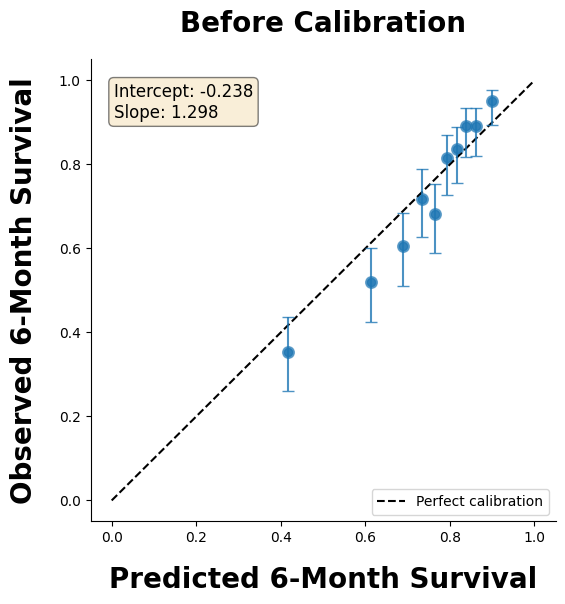

In [13]:
slope_orig, intercept_orig, _, _, _ = linregress(
    cal_df['predicted'], 
    cal_df['observed']
)

# Plot
plt.figure(figsize = (6, 6))
plt.scatter(cal_df['predicted'], cal_df['observed'], s = 70, alpha = 0.6)
plt.plot([0, 1], [0, 1], 'k--', label = 'Perfect calibration')

# Error bar 
yerr = np.vstack([
    cal_df['observed'] - cal_df['obs_lo'],
    cal_df['obs_hi'] - cal_df['observed']
])

plt.errorbar(
    cal_df['predicted'],
    cal_df['observed'],
    yerr = yerr,
    fmt = 'o',           
    elinewidth = 1.5,    
    capsize = 4,         
    alpha = 0.8
)

# Add text box with calibration metrics
textstr = f'Intercept: {intercept_orig:.3f}\nSlope: {slope_orig:.3f}'
plt.text(0.05, 0.95, textstr, transform = plt.gca().transAxes, 
         fontsize = 12, verticalalignment = 'top',
         bbox = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5))

plt.xlabel('Predicted 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.ylabel('Observed 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.title('Before Calibration',  weight = 'bold', size = 20, pad = 20)
plt.legend()

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

#plt.savefig('../outputs/uncalibrated_cox_6m_survival_prediction_plot.pdf', format = 'pdf', bbox_inches = 'tight')

plt.show()

## Isotonic Calibration Using Cross Validation 

In [14]:
# Prepare structured array for survival outcomes
y_dtype = [('event', bool), ('duration', float)]

y = np.array([tuple(x) for x in df[['event', 'duration']].values],
             dtype = y_dtype)

In [15]:
df, brier_scores = calibrate_survival_predictions(df, y, 'psurv_180', 180)


=== Fold 1/5 ===
Brier score at 180 days (calibrated): 0.1779

=== Fold 2/5 ===
Brier score at 180 days (calibrated): 0.1661

=== Fold 3/5 ===
Brier score at 180 days (calibrated): 0.1782

=== Fold 4/5 ===
Brier score at 180 days (calibrated): 0.1586

=== Fold 5/5 ===
Brier score at 180 days (calibrated): 0.1600

=== Summary ===
psurv_180_calibrated computed: 1257

=== Brier Scores at 180 days (calibrated) ===
Mean: 0.1682 ± 0.0085


In [16]:
df_final_calibrated = df[['PatientID', 'psurv_180_calibrated']]

In [17]:
df_final_calibrated.to_csv('../outputs/cox_6m_survival_predictions_calibrated.csv', index = False)

In [18]:
cal_iso_df = calculate_calibration_curve(df, 'psurv_180_calibrated', 180)

In [19]:
cal_iso_df

,bin,predicted,observed,n,obs_lo,obs_hi
0,"(-0.001, 0.51]",0.375917,0.420844,150,0.333820,0.497828
1,"(0.51, 0.574]",0.538831,0.528883,116,0.430441,0.614361
2,"(0.574, 0.675]",0.620894,0.600451,136,0.507342,0.677507
3,"(0.675, 0.687]",0.681211,0.726818,127,0.637507,0.795018
4,"(0.687, 0.774]",0.733274,0.669972,106,0.569964,0.751755
5,"(0.774, 0.814]",0.804342,0.810582,141,0.732274,0.865305
6,"(0.814, 0.871]",0.849950,0.837285,111,0.748446,0.893827
7,"(0.871, 0.9]",0.889728,0.915455,121,0.841862,0.949638
8,"(0.9, 0.949]",0.913748,0.868343,128,0.793064,0.916536
9,"(0.949, 1.0]",0.966380,0.949065,121,0.890128,0.976792


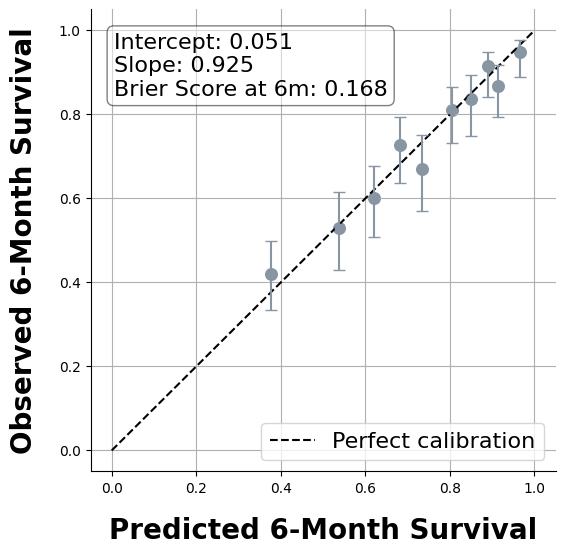

In [20]:
slope_iso, intercept_iso, _, _, _ = linregress(
    cal_iso_df['predicted'], 
    cal_iso_df['observed']
)

# Plot
plt.figure(figsize = (6, 6))
plt.scatter(cal_iso_df['predicted'], cal_iso_df['observed'], s = 70, color = '#8896A4')
plt.plot([0, 1], [0, 1], 'k--', label = 'Perfect calibration')

# Error bar 
yerr = np.vstack([
    cal_iso_df['observed'] - cal_iso_df['obs_lo'],
    cal_iso_df['obs_hi'] - cal_iso_df['observed']
])

plt.errorbar(
    cal_iso_df['predicted'],
    cal_iso_df['observed'],
    yerr = yerr,
    fmt = 'o',           
    elinewidth = 1.5,
    color = '#8896A4',
    capsize = 4
)

# Add text box with calibration metrics
textstr = f'Intercept: {intercept_iso:.3f}\nSlope: {slope_iso:.3f}\nBrier Score at 6m: {np.mean(brier_scores):.3f}'
plt.text(0.05, 0.95, textstr, transform = plt.gca().transAxes, 
         fontsize = 16, verticalalignment = 'top',
         bbox = dict(boxstyle = 'round', facecolor = 'white', alpha = 0.5))

plt.xlabel('Predicted 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.ylabel('Observed 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
#plt.title('After Isotonic Regression',  weight = 'bold', size = 20, pad = 20)
plt.legend(fontsize=16)
plt.grid(True)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

#plt.savefig('../outputs/calibrated_cox_6m_survival_prediction_plot.pdf', format = 'pdf', bbox_inches = 'tight')

plt.show()